# Book Recommendation System - Data Preparation & EDA
**Group 06**
- **Member:** Lê Kim Dũng
- **ID:** 28211452455
- **Role:** Data & Analysis Lead

This notebook covers:
1. Data collection and loading (Goodbooks-10k)
2. Data cleaning and preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature engineering / data preparation
5. References

## 0. Install and Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn kaggle

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# Setup visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Collection & Loading
Download the Goodbooks-10k dataset from Kaggle.
Make sure you have `kaggle.json` uploaded to your current directory or configured at `~/.kaggle/kaggle.json`.

In [3]:
# Setup kaggle.json for API access
import shutil
from pathlib import Path
import os

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)

if os.path.exists('kaggle.json'):
    shutil.copy('kaggle.json', kaggle_dir / 'kaggle.json')
    try:
        os.chmod(kaggle_dir / 'kaggle.json', 0o600)
    except:
        pass
    print("kaggle.json configured successfully.")
else:
    print("Make sure kaggle.json is configured at ~/.kaggle/kaggle.json")

kaggle.json configured successfully.


In [4]:
# Download dataset using Kaggle CLI
# Note: Sometimes !kaggle fails on Windows. If it does, you can run:
# import kaggle; kaggle.api.authenticate(); kaggle.api.dataset_download_files('zygmunt/goodbooks-10k', path='data', unzip=True)
!kaggle datasets download -d zygmunt/goodbooks-10k

# Unzip the downloaded file
import zipfile
if os.path.exists('goodbooks-10k.zip'):
    with zipfile.ZipFile('goodbooks-10k.zip', 'r') as zip_ref:
        zip_ref.extractall('data')
    print("Dataset extracted to 'data' folder.")

Dataset URL: https://www.kaggle.com/datasets/zygmunt/goodbooks-10k
License(s): CC-BY-SA-4.0
goodbooks-10k.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset extracted to 'data' folder.


In [5]:
# Load datasets into Pandas DataFrames
data_dir = 'data'
books = pd.read_csv(f'{data_dir}/books.csv')
ratings = pd.read_csv(f'{data_dir}/ratings.csv')
tags = pd.read_csv(f'{data_dir}/tags.csv')
book_tags = pd.read_csv(f'{data_dir}/book_tags.csv')

print(f"Books: {books.shape}")
print(f"Ratings: {ratings.shape}")
print(f"Tags: {tags.shape}")
print(f"Book Tags: {book_tags.shape}")

Books: (10000, 23)
Ratings: (981756, 3)
Tags: (34252, 2)
Book Tags: (999912, 3)


## 2. Data Cleaning & Preprocessing

In [6]:
# Display missing values in books dataframe
print("Missing values in books:")
print(books.isnull().sum()[books.isnull().sum() > 0])

Missing values in books:
isbn                          700
isbn13                        585
original_publication_year      21
original_title                585
language_code                1084
dtype: int64


In [7]:
# Fill missing values
# For original_publication_year, we can fill with the median
books['original_publication_year'] = books['original_publication_year'].fillna(books['original_publication_year'].median())

# For isbn and isbn13, missing values can be filled with 'Unknown'
books['isbn'] = books['isbn'].fillna('Unknown')
books['isbn13'] = books['isbn13'].fillna('Unknown')

# For original_title, if missing, we use title
books['original_title'] = books['original_title'].fillna(books['title'])

# Drop rows with language_code missing as it's very few, or just fill with 'eng'
books['language_code'] = books['language_code'].fillna('eng')

print("After cleaning, missing values:")
print(books.isnull().sum().sum())

After cleaning, missing values:
0


In [8]:
# Check for duplicates in ratings
print("Duplicate ratings:", ratings.duplicated().sum())
# Drop duplicates if any
ratings = ratings.drop_duplicates()

Duplicate ratings: 1644


## 3. Exploratory Data Analysis (EDA)

C:\Users\ASUS-PRO\AppData\Local\Temp\ipykernel_29800\1188940087.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings, x='rating', palette='viridis')


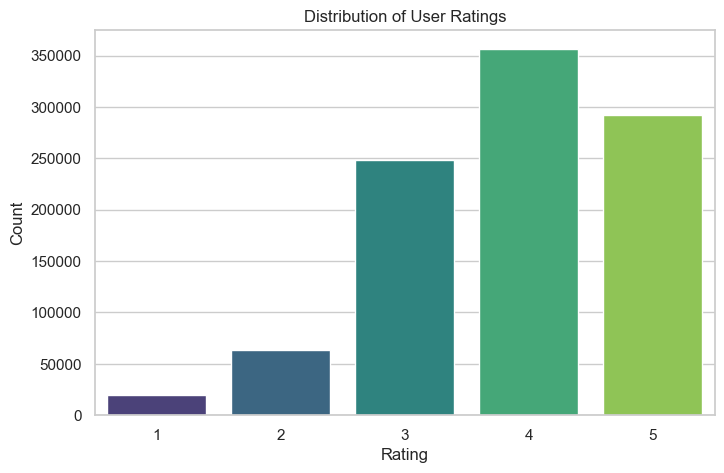

In [9]:
# 3.1 Distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(data=ratings, x='rating', palette='viridis')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

C:\Users\ASUS-PRO\AppData\Local\Temp\ipykernel_29800\3949723822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_books, x='ratings_count', y='title', palette='magma')


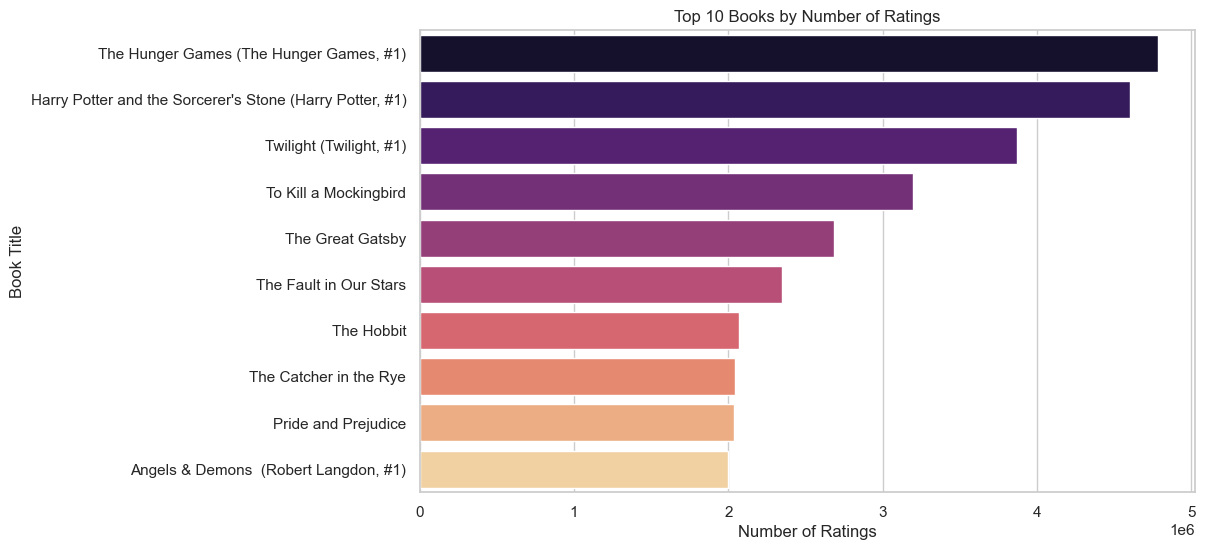

In [10]:
# 3.2 Top 10 most rated books
top_books = books.sort_values('ratings_count', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_books, x='ratings_count', y='title', palette='magma')
plt.title('Top 10 Books by Number of Ratings')
plt.xlabel('Number of Ratings')
plt.ylabel('Book Title')
plt.show()

C:\Users\ASUS-PRO\AppData\Local\Temp\ipykernel_29800\3251958303.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=highly_rated, x='average_rating', y='title', palette='crest')


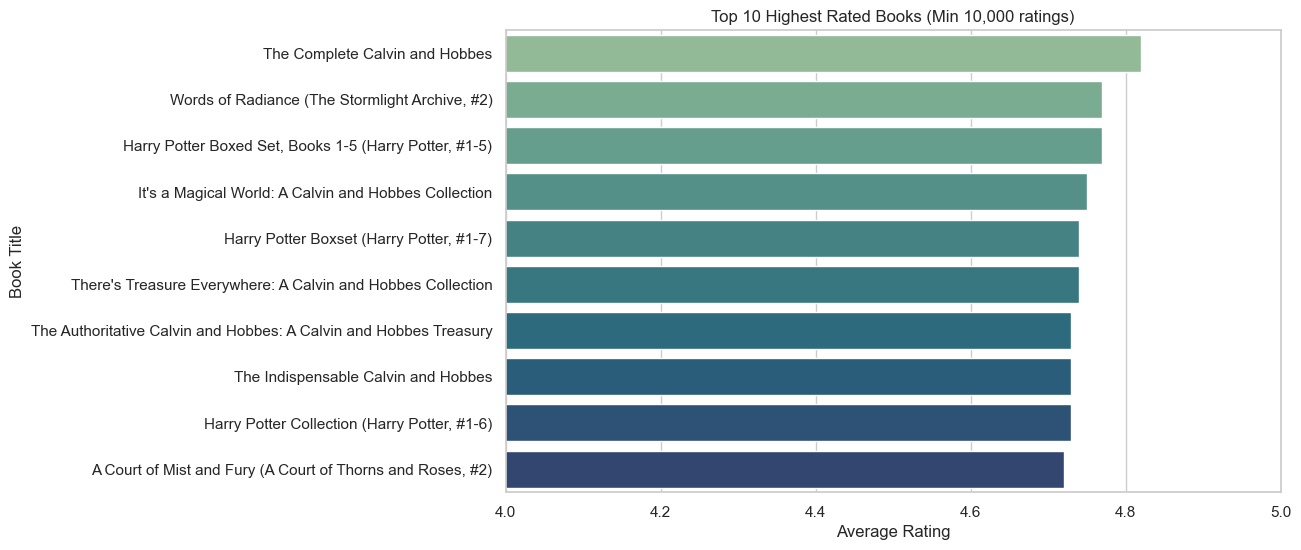

In [11]:
# 3.3 Top 10 highly rated books (with at least 10,000 ratings)
highly_rated = books[books['ratings_count'] > 10000].sort_values('average_rating', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=highly_rated, x='average_rating', y='title', palette='crest')
plt.title('Top 10 Highest Rated Books (Min 10,000 ratings)')
plt.xlabel('Average Rating')
plt.ylabel('Book Title')
plt.xlim(4.0, 5.0)
plt.show()

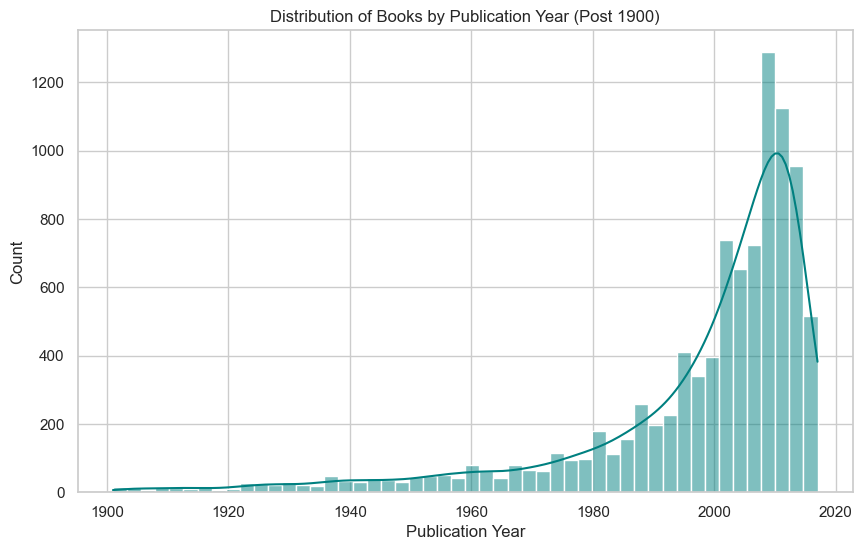

In [12]:
# 3.4 Distribution of Publication Years
plt.figure(figsize=(10, 6))
sns.histplot(books[books['original_publication_year'] > 1900]['original_publication_year'], bins=50, kde=True, color='teal')
plt.title('Distribution of Books by Publication Year (Post 1900)')
plt.xlabel('Publication Year')
plt.ylabel('Count')
plt.show()

## 4. Feature Engineering / Data Preparation
We will prepare data for two types of recommendation systems:
1. **Collaborative Filtering:** Creating a user-item interaction matrix.
2. **Content-Based Filtering:** Combining text features like authors and tags into a single text representation for each book.

In [13]:
# 4.1 Collaborative Filtering Preparation
from scipy.sparse import csr_matrix

n_users = ratings['user_id'].nunique()
n_books = ratings['book_id'].nunique()

print(f"Number of unique users: {n_users}")
print(f"Number of unique books: {n_books}")

# Create sparse user-item interaction matrix
user_item_matrix = csr_matrix((ratings['rating'], (ratings['user_id'], ratings['book_id'])))
print("User-Item Matrix shape:", user_item_matrix.shape)

Number of unique users: 53424
Number of unique books: 10000
User-Item Matrix shape: (53425, 10001)


In [14]:
# 4.2 Content-Based Filtering Preparation
# Merge tags with book_tags
merged_tags = pd.merge(book_tags, tags, on='tag_id')

# Group tags by book
book_tags_grouped = merged_tags.groupby('goodreads_book_id')['tag_name'].apply(lambda x: ' '.join(x)).reset_index()

# Merge with books dataset
# Note: In books.csv, the goodreads ID is stored in 'book_id', while 'id' is the 1-10000 index
books_with_tags = pd.merge(books, book_tags_grouped, left_on='book_id', right_on='goodreads_book_id', how='left')
books_with_tags['tag_name'] = books_with_tags['tag_name'].fillna('')
books_with_tags['authors'] = books_with_tags['authors'].fillna('')

# Combine authors and tags for text processing
books_with_tags['content_features'] = books_with_tags['authors'] + " " + books_with_tags['tag_name']

print("Sample content features:")
print(books_with_tags[['title', 'content_features']].head(3))

Sample content features:
                                               title  \
0            The Hunger Games (The Hunger Games, #1)   
1  Harry Potter and the Sorcerer's Stone (Harry P...   
2                            Twilight (Twilight, #1)   

                                    content_features  
0  Suzanne Collins favorites currently-reading yo...  
1  J.K. Rowling, Mary GrandPré to-read favorites ...  
2  Stephenie Meyer young-adult fantasy favorites ...  


In [15]:
# Save prepared data for the Modeling step (Thành viên 2)
import os
os.makedirs('data', exist_ok=True)
books_with_tags.to_csv('data/books_cleaned_with_features.csv', index=False)
print("Data preparation complete and saved to data/books_cleaned_with_features.csv")

Data preparation complete and saved to data/books_cleaned_with_features.csv


## 5. References
*(APA Format)*

- McKinney, W. (2010). Data structures for statistical computing in python. In *Proceedings of the 9th Python in Science Conference* (Vol. 445, pp. 51-56).
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of machine learning research*, 12(Oct), 2825-2830.
- Waskom, M. L. (2021). Seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), 3021. https://doi.org/10.21105/joss.03021
- Zygmunt, Z. (2017). Goodbooks-10k [Data set]. Kaggle. https://www.kaggle.com/datasets/zygmunt/goodbooks-10k